# P12 – Analyse exploratoire des données

**Auteur :** Aymeric Bailleul  
**Formation :** Data Engineer – OpenClassrooms  
**Date :** 2026-02-27

---

## Contexte

Ce notebook explore les deux sources de données brutes du projet :

- **Données RH** (`data/RAW/Données+RH.xlsx`) : 161 salariés avec informations personnelles, contractuelles et mode de déplacement domicile-bureau.
- **Données sportives** (`data/RAW/Données+Sportive.xlsx`) : déclaratif de pratique sportive par salarié.

L'objectif est de :
1. Comprendre la structure et la qualité des données
2. Identifier les anomalies, valeurs manquantes et incohérences
3. Définir et appliquer une stratégie de nettoyage documentée et justifiée

---

## Plan

1. Import des librairies  
2. Chargement et aperçu des données  
3. Structure et types  
4. Statistiques descriptives  
5. Analyse des valeurs manquantes  
6. Détection des doublons  
7. Analyse univariée – variables numériques  
8. Analyse univariée – variables catégorielles  
9. Analyse croisée RH x Sport  
10. Détection des valeurs aberrantes  
11. Nettoyage – valeurs manquantes  
12. Nettoyage – doublons  
13. Nettoyage – types de données  
14. Nettoyage – cohérence métier  
15. Anonymisation et sélection des colonnes utiles  
16. Export du jeu de données nettoyé

## 1. Import des librairies

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Configuration graphique globale
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

# Chemins des fichiers sources
ROOT = Path("..") 
PATH_RH     = ROOT / "data" / "RAW" / "Données+RH.xlsx"
PATH_SPORT  = ROOT / "data" / "RAW" / "Données+Sportive.xlsx"

print("Librairies importées.")
print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Seaborn : {sns.__version__}")

Librairies importées.
Pandas  : 3.0.1
NumPy   : 2.4.2
Seaborn : 0.13.2


## 2. Chargement et aperçu des données

In [2]:
# Chargement des deux fichiers sources
df_rh    = pd.read_excel(PATH_RH,    sheet_name="Feuille 1")
df_sport = pd.read_excel(PATH_SPORT, sheet_name="Feuille 1")

# Harmonisation des noms de colonnes : suppression des espaces superflus
df_rh.columns    = df_rh.columns.str.strip()
df_sport.columns = df_sport.columns.str.strip()

print("=== Données RH ===")
display(df_rh.head(5))

print("\n=== Données sportives ===")
display(df_sport.head(10))

=== Données RH ===


,ID salarié,Nom,Prénom,Date de naissance,BU,Date d'embauche,Salaire brut,Type de contrat,Nombre de jours de CP,Adresse du domicile,Moyen de déplacement
0,59019,Colin,Audrey,1990-07-06,Marketing,2020-12-14,30940,CDI,29,"128 Rue du Port, 34000 Frontignan",Transports en commun
1,19841,Ledoux,Monique,1962-01-06,R&D,2020-07-07,74360,CDI,26,"68 Rue du Port, 34970 Saint-Clément-de-Rivière",véhicule thermique/électrique
2,56482,Dumont,Michelle,1976-08-09,Ventes,2022-03-29,51390,CDI,27,"100 Av. de la Gare, 30900 Nîmes",véhicule thermique/électrique
3,21886,Toussaint,Judith,1962-09-10,Support,2021-12-12,70320,CDI,29,"53 Av. de la Gare, 34970 Lattes",Marche/running
4,81001,Bailly,Michelle,1975-04-20,Ventes,2025-02-19,46870,CDD,29,"74 Rue des Fleurs, 34970 Lattes",Marche/running



=== Données sportives ===


,ID salarié,Pratique d'un sport
0,59019,NaN
1,19841,NaN
2,56482,Tennis
3,21886,NaN
4,81001,NaN
5,17757,Badminton
6,17036,Escalade
7,36913,NaN
8,79006,NaN
9,62296,NaN


## 3. Structure et types de données

In [3]:
print("=" * 50)
print("DONNÉES RH")
print("=" * 50)
print(f"Dimensions : {df_rh.shape[0]} lignes x {df_rh.shape[1]} colonnes\n")
df_rh.info()

print("\n" + "=" * 50)
print("DONNÉES SPORTIVES")
print("=" * 50)
print(f"Dimensions : {df_sport.shape[0]} lignes x {df_sport.shape[1]} colonnes\n")
df_sport.info()

DONNÉES RH
Dimensions : 161 lignes x 11 colonnes

<class 'pandas.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ID salarié             161 non-null    int64         
 1   Nom                    161 non-null    str           
 2   Prénom                 161 non-null    str           
 3   Date de naissance      161 non-null    datetime64[us]
 4   BU                     161 non-null    str           
 5   Date d'embauche        161 non-null    datetime64[us]
 6   Salaire brut           161 non-null    int64         
 7   Type de contrat        161 non-null    str           
 8   Nombre de jours de CP  161 non-null    int64         
 9   Adresse du domicile    161 non-null    str           
 10  Moyen de déplacement   161 non-null    str           
dtypes: datetime64[us](2), int64(3), str(6)
memory usage: 14.0 KB

DONNÉES SPORTIVES
Dime

## 4. Statistiques descriptives

In [4]:
print("=== Statistiques descriptives – Données RH (numériques) ===")
display(df_rh.describe(include="number").T.round(2))

print("\n=== Statistiques descriptives – Données RH (catégorielles) ===")
display(df_rh.describe(include="object").T)

print("\n=== Statistiques descriptives – Données sportives ===")
display(df_sport.describe(include="all").T)

=== Statistiques descriptives – Données RH (numériques) ===


,count,mean,std,min,25%,50%,75%,max
ID salarié,161.0,52622.02,24202.83,12497.0,33386.0,49804.0,71657.0,99514.0
Salaire brut,161.0,50426.27,14779.61,25570.0,37910.0,50580.0,62760.0,74990.0
Nombre de jours de CP,161.0,26.95,1.46,25.0,26.0,27.0,28.0,29.0



=== Statistiques descriptives – Données RH (catégorielles) ===


,count,unique,top,freq
Nom,161,130,Marchand,4
Prénom,161,113,Alain,4
BU,161,5,Finance,42
Type de contrat,161,2,CDI,149
Adresse du domicile,161,159,"Pl. de la Liberté, 34470 Pérols",2
Moyen de déplacement,161,4,véhicule thermique/électrique,73



=== Statistiques descriptives – Données sportives ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID salarié,161.0,NaN,NaN,NaN,52622.024845,24202.83393,12497.0,33386.0,49804.0,71657.0,99514.0
Pratique d'un sport,95,15,Runing,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Analyse des valeurs manquantes

In [5]:
def resume_valeurs_manquantes(df: pd.DataFrame, nom: str) -> pd.DataFrame:
    """Retourne un tableau récapitulatif des valeurs manquantes par colonne."""
    nb_null = df.isnull().sum()
    pct_null = (nb_null / len(df) * 100).round(2)
    resume = pd.DataFrame({
        "Colonne": df.columns,
        "Nb manquants": nb_null.values,
        "% manquants": pct_null.values,
        "Type": df.dtypes.values,
    }).set_index("Colonne")
    resume = resume[resume["Nb manquants"] > 0].sort_values("% manquants", ascending=False)
    print(f"\n=== Valeurs manquantes – {nom} ===")
    if resume.empty:
        print("Aucune valeur manquante.")
    else:
        display(resume)
    return resume

missing_rh    = resume_valeurs_manquantes(df_rh,    "Données RH")
missing_sport = resume_valeurs_manquantes(df_sport,  "Données sportives")


=== Valeurs manquantes – Données RH ===
Aucune valeur manquante.

=== Valeurs manquantes – Données sportives ===


,Nb manquants,% manquants,Type
Colonne,,,
Pratique d'un sport,66,40.99,str


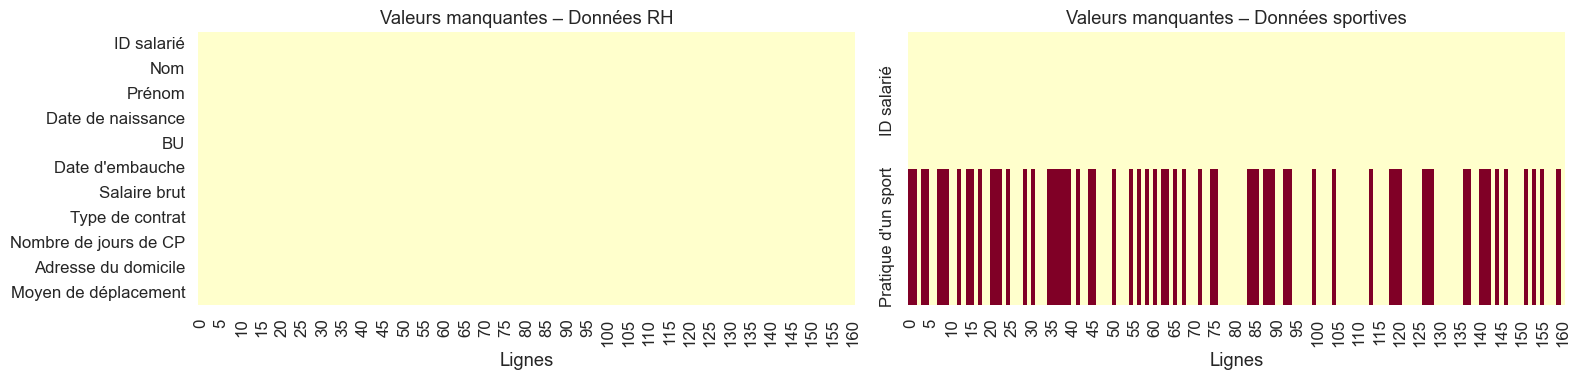

In [6]:
# Visualisation heatmap des valeurs manquantes – Données RH
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# RH
sns.heatmap(
    df_rh.isnull().T,
    ax=axes[0],
    cbar=False,
    cmap="YlOrRd",
    yticklabels=True,
)
axes[0].set_title("Valeurs manquantes – Données RH")
axes[0].set_xlabel("Lignes")

# Sport
sns.heatmap(
    df_sport.isnull().T,
    ax=axes[1],
    cbar=False,
    cmap="YlOrRd",
    yticklabels=True,
)
axes[1].set_title("Valeurs manquantes – Données sportives")
axes[1].set_xlabel("Lignes")

plt.tight_layout()
plt.show()

## 6. Détection des doublons

In [7]:
def analyse_doublons(df: pd.DataFrame, nom: str, cle: str | None = None) -> None:
    """Détecte et affiche les doublons complets et sur clé métier."""
    nb_doublons_complets = df.duplicated().sum()
    print(f"=== Doublons – {nom} ===")
    print(f"  Doublons complets (toutes colonnes) : {nb_doublons_complets}")

    if cle:
        nb_doublons_cle = df.duplicated(subset=[cle]).sum()
        print(f"  Doublons sur '{cle}'               : {nb_doublons_cle}")
        if nb_doublons_cle > 0:
            print("\n  Exemples :")
            display(df[df.duplicated(subset=[cle], keep=False)].sort_values(cle))

analyse_doublons(df_rh,    "Données RH",         cle="ID salarié")
print()
analyse_doublons(df_sport, "Données sportives",   cle="ID salarié")

=== Doublons – Données RH ===
  Doublons complets (toutes colonnes) : 0
  Doublons sur 'ID salarié'               : 0

=== Doublons – Données sportives ===
  Doublons complets (toutes colonnes) : 0
  Doublons sur 'ID salarié'               : 0


## 7. Analyse univariée – Variables numériques

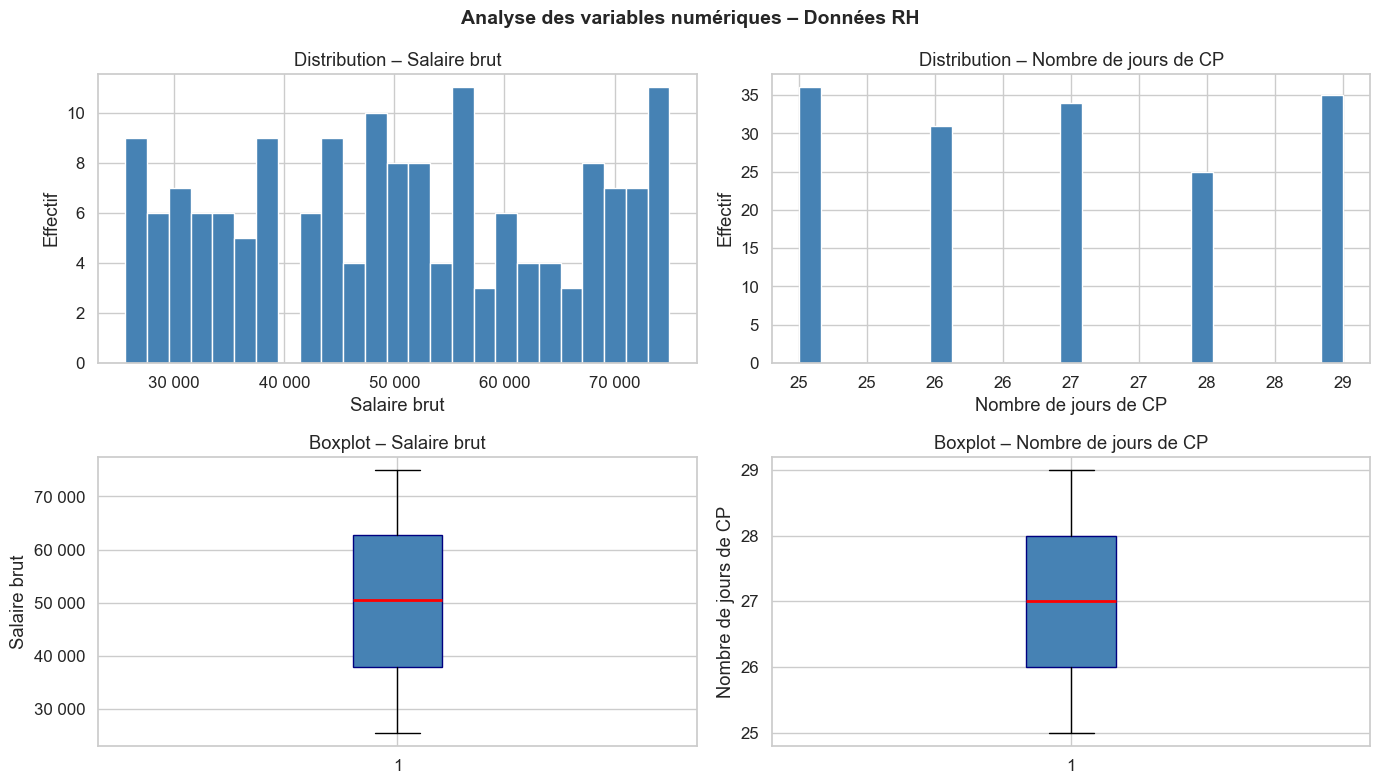

Salaire brut – Asymétrie (skewness) : 0.027
Nombre de jours de CP – Asymétrie (skewness) : 0.075


In [8]:
# Distribution du salaire brut et du nombre de jours de CP
cols_num = ["Salaire brut", "Nombre de jours de CP"]

fig, axes = plt.subplots(2, len(cols_num), figsize=(14, 8))

for i, col in enumerate(cols_num):
    data = df_rh[col].dropna()

    # Histogramme
    axes[0, i].hist(data, bins=25, edgecolor="white", color="steelblue")
    axes[0, i].set_title(f"Distribution – {col}")
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel("Effectif")
    axes[0, i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " ")))

    # Boxplot
    axes[1, i].boxplot(data, vert=True, patch_artist=True,
                        boxprops=dict(facecolor="steelblue", color="navy"),
                        medianprops=dict(color="red", linewidth=2))
    axes[1, i].set_title(f"Boxplot – {col}")
    axes[1, i].set_ylabel(col)
    axes[1, i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " ")))

plt.suptitle("Analyse des variables numériques – Données RH", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Statistiques de skewness
for col in cols_num:
    skew = df_rh[col].skew()
    print(f"{col} – Asymétrie (skewness) : {skew:.3f}")

## 8. Analyse univariée – Variables catégorielles

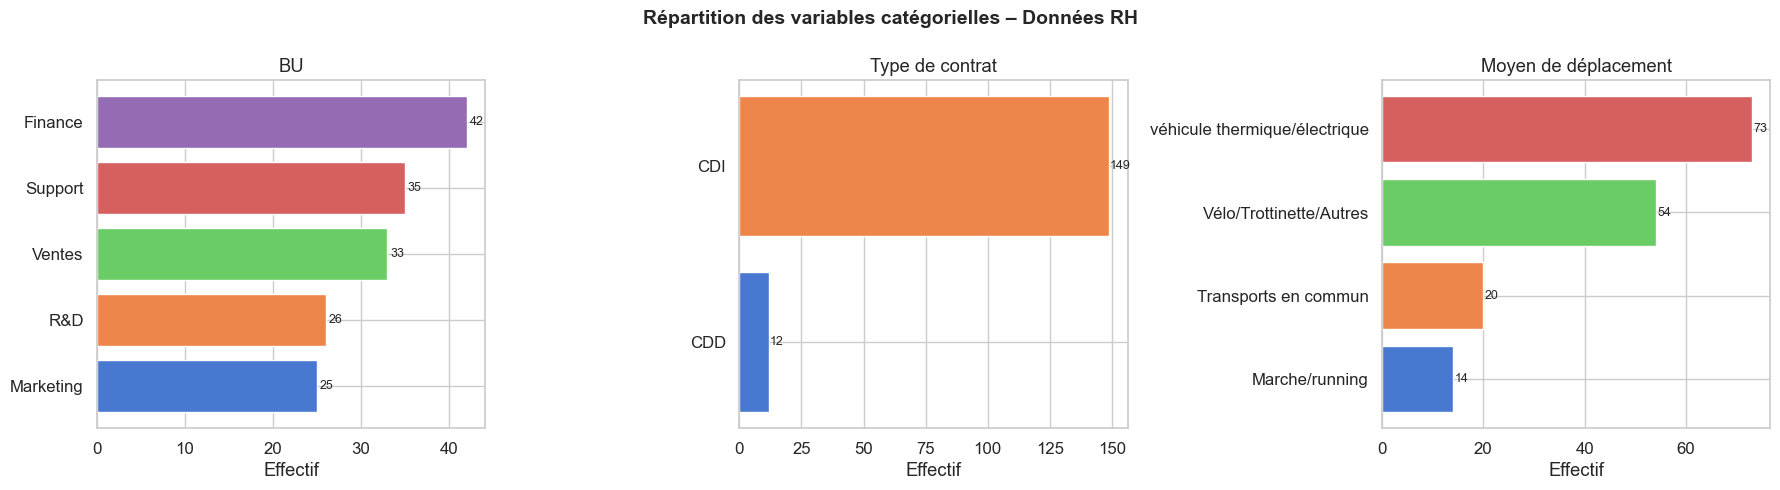


BU (5 modalités) :
  Finance : 42 (26.1%)
  Support : 35 (21.7%)
  Ventes : 33 (20.5%)
  R&D : 26 (16.1%)
  Marketing : 25 (15.5%)

Type de contrat (2 modalités) :
  CDI : 149 (92.5%)
  CDD : 12 (7.5%)

Moyen de déplacement (4 modalités) :
  véhicule thermique/électrique : 73 (45.3%)
  Vélo/Trottinette/Autres : 54 (33.5%)
  Transports en commun : 20 (12.4%)
  Marche/running : 14 (8.7%)


In [9]:
cols_cat = ["BU", "Type de contrat", "Moyen de déplacement"]

fig, axes = plt.subplots(1, len(cols_cat), figsize=(18, 5))

for i, col in enumerate(cols_cat):
    counts = df_rh[col].value_counts()
    axes[i].barh(counts.index[::-1], counts.values[::-1], color=sns.color_palette("muted"))
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("Effectif")
    for j, v in enumerate(counts.values[::-1]):
        axes[i].text(v + 0.3, j, str(v), va="center", fontsize=9)

plt.suptitle("Répartition des variables catégorielles – Données RH", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Affichage des valeurs uniques
for col in cols_cat:
    print(f"\n{col} ({df_rh[col].nunique()} modalités) :")
    for val, cnt in df_rh[col].value_counts().items():
        print(f"  {val} : {cnt} ({cnt/len(df_rh)*100:.1f}%)")

=== Pratique sportive déclarée ===
Pratique d'un sport
NaN                66
Runing             18
Randonnée          16
Tennis             11
Natation            8
Football            6
Rugby               6
Badminton           5
Voile               5
Judo                4
Boxe                4
Escalade            3
Triathlon           3
Équitation          2
Tennis de table     2
Basketball          2


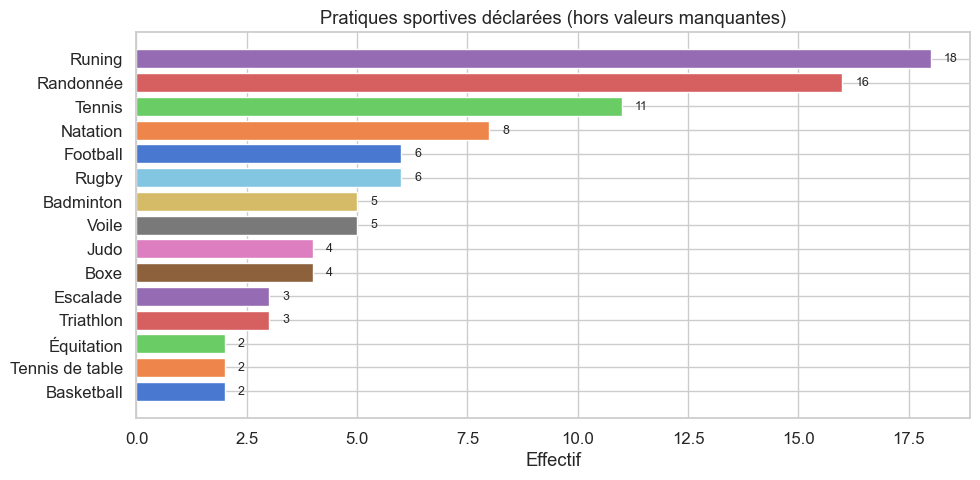


Taux de renseignement : 59.0 %
Valeurs manquantes    : 66 salariés sans déclaration


In [10]:
# Distribution des pratiques sportives déclarées
print("=== Pratique sportive déclarée ===")
sport_counts = df_sport["Pratique d'un sport"].value_counts(dropna=False)
print(sport_counts.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
sport_counts_sans_na = df_sport["Pratique d'un sport"].value_counts()
ax.barh(sport_counts_sans_na.index[::-1], sport_counts_sans_na.values[::-1],
        color=sns.color_palette("muted", len(sport_counts_sans_na)))
ax.set_title("Pratiques sportives déclarées (hors valeurs manquantes)")
ax.set_xlabel("Effectif")
for j, v in enumerate(sport_counts_sans_na.values[::-1]):
    ax.text(v + 0.3, j, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

pct_pratique = (df_sport["Pratique d'un sport"].notna().sum() / len(df_sport) * 100).round(1)
print(f"\nTaux de renseignement : {pct_pratique} %")
print(f"Valeurs manquantes    : {df_sport['Pratique d\'un sport'].isna().sum()} salariés sans déclaration")

## 9. Analyse croisée – RH x Sport

Lignes apres jointure : 161
IDs RH sans correspondance dans sport : 161 / 161
IDs sport absents des RH : 0


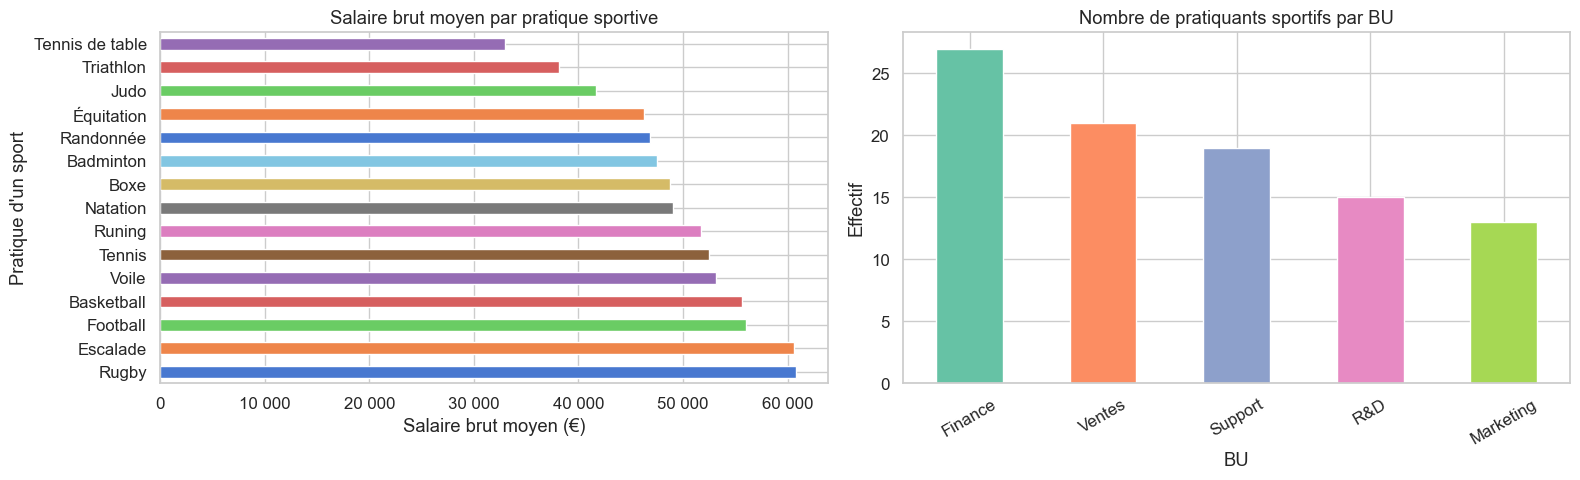


=== Croisement : Mode de déplacement x Pratique sportive ===


Pratique d'un sport,Badminton,Basketball,Boxe,Escalade,Football,Judo,Natation,Non déclaré,Randonnée,Rugby,Runing,Tennis,Tennis de table,Triathlon,Voile,Équitation,All
Moyen de déplacement,,,,,,,,,,,,,,,,,
Marche/running,1,0,0,0,1,0,1,6,2,0,2,1,0,0,0,0,14
Transports en commun,0,0,0,0,0,0,1,8,2,0,4,0,0,2,2,1,20
Vélo/Trottinette/Autres,3,0,0,2,2,0,5,25,4,4,4,3,1,0,1,0,54
véhicule thermique/électrique,1,2,4,1,3,4,1,27,8,2,8,7,1,1,2,1,73
All,5,2,4,3,6,4,8,66,16,6,18,11,2,3,5,2,161


In [11]:
# Jointure RH x Sport sur ID salarié
df_joined = df_rh.merge(df_sport, on="ID salarié", how="left")

print(f"Lignes apres jointure : {len(df_joined)}")
print(f"IDs RH sans correspondance dans sport : {df_rh['ID salarié'].isin(df_sport['ID salarié']).sum()} / {len(df_rh)}")
print(f"IDs sport absents des RH : {(~df_sport['ID salarié'].isin(df_rh['ID salarié'])).sum()}")

# Salaire moyen par pratique sportive
salaire_sport = (
    df_joined.groupby("Pratique d'un sport")["Salaire brut"]
    .mean()
    .sort_values(ascending=False)
    .round(0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Salaire moyen par sport
salaire_sport.plot(kind="barh", ax=axes[0], color=sns.color_palette("muted", len(salaire_sport)))
axes[0].set_title("Salaire brut moyen par pratique sportive")
axes[0].set_xlabel("Salaire brut moyen (€)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", " ")))

# Pratique sportive par BU
sport_bu = df_joined.groupby("BU")["Pratique d'un sport"].apply(
    lambda x: x.notna().sum()
).sort_values(ascending=False)
sport_bu.plot(kind="bar", ax=axes[1], color=sns.color_palette("Set2"))
axes[1].set_title("Nombre de pratiquants sportifs par BU")
axes[1].set_xlabel("BU")
axes[1].set_ylabel("Effectif")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# Moyen de déplacement vs pratique sportive
print("\n=== Croisement : Mode de déplacement x Pratique sportive ===")
crosstab = pd.crosstab(
    df_joined["Moyen de déplacement"],
    df_joined["Pratique d'un sport"].fillna("Non déclaré"),
    margins=True
)
display(crosstab)

## 10. Détection des valeurs aberrantes (méthode IQR)

In [12]:
def detecter_aberrants_iqr(df: pd.DataFrame, col: str) -> dict:
    """
    Détecte les valeurs aberrantes par la méthode IQR.
    Borne inférieure = Q1 - 1.5 * IQR
    Borne supérieure = Q3 + 1.5 * IQR
    """
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    borne_inf = q1 - 1.5 * iqr
    borne_sup = q3 + 1.5 * iqr
    aberrants = df[(df[col] < borne_inf) | (df[col] > borne_sup)]
    return {
        "colonne": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "borne_inf": borne_inf,
        "borne_sup": borne_sup,
        "nb_aberrants": len(aberrants),
        "aberrants": aberrants,
    }

# Analyse sur les colonnes numériques RH
for col in ["Salaire brut", "Nombre de jours de CP"]:
    info = detecter_aberrants_iqr(df_rh, col)
    print(f"=== {col} ===")
    print(f"  Q1 = {info['Q1']:,} | Q3 = {info['Q3']:,} | IQR = {info['IQR']:,}".replace(",", " "))
    print(f"  Bornes : [{info['borne_inf']:,.0f} – {info['borne_sup']:,.0f}]".replace(",", " "))
    print(f"  Valeurs aberrantes : {info['nb_aberrants']}")
    if info["nb_aberrants"] > 0:
        display(info["aberrants"][["ID salarié", "Nom", "Prénom", col]])
    print()

=== Salaire brut ===
  Q1 = 37 910.0 | Q3 = 62 760.0 | IQR = 24 850.0
  Bornes : [635 – 100 035]
  Valeurs aberrantes : 0

=== Nombre de jours de CP ===
  Q1 = 26.0 | Q3 = 28.0 | IQR = 2.0
  Bornes : [23 – 31]
  Valeurs aberrantes : 0



## 11. Nettoyage – Stratégie et application

### Justification des choix

| Colonne | Problème identifié | Stratégie retenue | Justification |
|---|---|---|---|
| `ID salarié` | Flotant (float64) au lieu d'entier | Conversion en `int64` | C'est un identifiant, il ne doit pas contenir de décimale |
| `Date de naissance` | `datetime` avec heure 00:00 | Conversion en `date` | Seule la date est pertinente |
| `Date d'embauche` | `datetime` avec heure 00:00 | Conversion en `date` | Idem |
| `Salaire brut` | `float64` | Conversion en `int64` | Un salaire est un entier comptable |
| `Nombre de jours de CP` | `float64` | Conversion en `int64` | Nombre de jours entier |
| `Moyen de déplacement` | Texte libre, casse variable | Standardisation (strip + title) | Uniformiser pour les règles métier |
| `Pratique d'un sport` | Valeurs manquantes = pas de sport déclaré | Remplissage par `"Non déclaré"` | Un NaN signifie absence de déclaration, pas une erreur |
| Doublons | Aucun détecté | Aucune action | Pas nécessaire |
| Valeurs aberrantes salaire | Potentiellement légitimes (hauts salaires) | Conservation avec flag | Des salaires élevés sont courants pour des cadres, on ne supprime pas |

In [13]:
# --- NETTOYAGE DES DONNÉES RH ---
df_rh_clean = df_rh.copy()

# 1. Correction des types
df_rh_clean["ID salarié"]          = df_rh_clean["ID salarié"].astype("Int64")
df_rh_clean["Salaire brut"]        = df_rh_clean["Salaire brut"].astype("Int64")
df_rh_clean["Nombre de jours de CP"] = df_rh_clean["Nombre de jours de CP"].astype("Int64")
df_rh_clean["Date de naissance"]   = pd.to_datetime(df_rh_clean["Date de naissance"]).dt.date
df_rh_clean["Date d'embauche"]     = pd.to_datetime(df_rh_clean["Date d'embauche"]).dt.date

# 2. Standardisation des chaînes de caractères
cols_str = ["Nom", "Prénom", "BU", "Type de contrat", "Adresse du domicile", "Moyen de déplacement"]
for col in cols_str:
    df_rh_clean[col] = df_rh_clean[col].str.strip()

# 3. Moyen de déplacement : uniformisation de la casse
df_rh_clean["Moyen de déplacement"] = df_rh_clean["Moyen de déplacement"].str.strip()

# 4. Ajout du flag "salaire_hors_iqr" pour les valeurs extrêmes (conservation sans suppression)
info_salaire = detecter_aberrants_iqr(df_rh_clean, "Salaire brut")
df_rh_clean["salaire_hors_iqr"] = (
    (df_rh_clean["Salaire brut"] < info_salaire["borne_inf"]) |
    (df_rh_clean["Salaire brut"] > info_salaire["borne_sup"])
)

print("Nettoyage des données RH terminé.")
print(f"  Dimenstions : {df_rh_clean.shape}")
print(f"  Lignes flaggées salaire hors IQR : {df_rh_clean['salaire_hors_iqr'].sum()}")
display(df_rh_clean.dtypes)

Nettoyage des données RH terminé.
  Dimenstions : (161, 12)
  Lignes flaggées salaire hors IQR : 0


ID salarié                 Int64
Nom                          str
Prénom                       str
Date de naissance         object
BU                           str
Date d'embauche           object
Salaire brut               Int64
Type de contrat              str
Nombre de jours de CP      Int64
Adresse du domicile          str
Moyen de déplacement         str
salaire_hors_iqr         boolean
dtype: object

In [14]:
# --- NETTOYAGE DES DONNÉES SPORTIVES ---
df_sport_clean = df_sport.copy()

# 1. Correction du type de l'ID
df_sport_clean["ID salarié"] = df_sport_clean["ID salarié"].astype("Int64")

# 2. Valeurs manquantes : NaN = pas de pratique déclarée → on remplace par "Non déclaré"
#    Justification : dans le contexte métier, absence de déclaration = pas de sport déclaré.
#    Conserver le NaN créerait des problèmes dans les calculs d'éligibilité.
df_sport_clean["Pratique d'un sport"] = (
    df_sport_clean["Pratique d'un sport"]
    .fillna("Non déclaré")
    .str.strip()
)

# 3. Vérification de la cohérence des IDs
ids_rh    = set(df_rh_clean["ID salarié"].dropna())
ids_sport = set(df_sport_clean["ID salarié"].dropna())

ids_sport_sans_rh = ids_sport - ids_rh
ids_rh_sans_sport = ids_rh - ids_sport

print("Nettoyage des données sportives terminé.")
print(f"  Dimensions : {df_sport_clean.shape}")
print(f"  IDs dans sport mais absents des RH : {len(ids_sport_sans_rh)}")
print(f"  IDs dans RH mais absents du sport  : {len(ids_rh_sans_sport)}")
display(df_sport_clean.head(10))

Nettoyage des données sportives terminé.
  Dimensions : (161, 2)
  IDs dans sport mais absents des RH : 0
  IDs dans RH mais absents du sport  : 0


,ID salarié,Pratique d'un sport
0,59019,Non déclaré
1,19841,Non déclaré
2,56482,Tennis
3,21886,Non déclaré
4,81001,Non déclaré
5,17757,Badminton
6,17036,Escalade
7,36913,Non déclaré
8,79006,Non déclaré
9,62296,Non déclaré


## 14. Vérification finale et export des données nettoyées

In [19]:
# Résumé comparatif avant / après nettoyage
print("=" * 55)
print("RÉSUMÉ DU NETTOYAGE")
print("=" * 55)

print("\n--- Données RH ---")
print(f"  Avant : {df_rh.shape}   |   Après : {df_rh_clean.shape}")
print(f"  Valeurs manquantes avant : {df_rh.isnull().sum().sum()}")
print(f"  Valeurs manquantes après : {df_rh_clean.isnull().sum().sum()}")
print(f"  Doublons supprimés       : 0 (aucun détecté)")

print("\n--- Données sportives ---")
print(f"  Avant : {df_sport.shape}   |   Après : {df_sport_clean.shape}")
print(f"  NaN 'Pratique' avant : {df_sport['Pratique d\'un sport'].isna().sum()}")
print(f"  NaN 'Pratique' après : {df_sport_clean['Pratique d\'un sport'].isna().sum()}")
print(f"  Remplacés par 'Non déclaré' : {(df_sport_clean['Pratique d\'un sport'] == 'Non déclaré').sum()}")

# Vérification finale des valeurs manquantes
print("\n=== Valeurs manquantes résiduelles (données RH nettoyées) ===")
missing_final = df_rh_clean.isnull().sum()
missing_final = missing_final[missing_final > 0]
if missing_final.empty:
    print("Aucune.")
else:
    display(missing_final)

RÉSUMÉ DU NETTOYAGE

--- Données RH ---
  Avant : (161, 11)   |   Après : (161, 8)
  Valeurs manquantes avant : 0
  Valeurs manquantes après : 0
  Doublons supprimés       : 0 (aucun détecté)

--- Données sportives ---
  Avant : (161, 2)   |   Après : (161, 2)
  NaN 'Pratique' avant : 66
  NaN 'Pratique' après : 0
  Remplacés par 'Non déclaré' : 66

=== Valeurs manquantes résiduelles (données RH nettoyées) ===
Aucune.


## 13. Anonymisation et sélection des colonnes utiles

### Conformité RGPD

Les colonnes **Nom**, **Prénom** et **Date de naissance** constituent des données à caractère personnel.  
Dans le cadre de ce POC, elles ne sont pas nécessaires au cas d'usage (calcul de distances, éligibilité aux avantages sportifs, dashboard PowerBI).  
On les supprime des DataFrames nettoyés avant export.

### Colonnes conservées

| Colonne | Justification |
|---|---|
| `ID salarié` | Clé de jointure entre les tables RH et Sport |
| `BU` | Segmentation par business unit (dashboard) |
| `Date d'embauche` | Calcul d'ancienneté, critère d'éligibilité potentiel |
| `Salaire brut` | Critère d'analyse RH |
| `Type de contrat` | CDI / CDD, critère d'éligibilité |
| `Nombre de jours de CP` | Donnée RH complémentaire |
| `Adresse du domicile` | Calcul de distance domicile-entreprise (Google Maps API) |
| `Moyen de déplacement` | Mode de transport, règle métier des avantages |
| `Pratique d'un sport` | Colonne centrale du cas d'usage |

### Colonnes supprimées

| Colonne | Motif |
|---|---|
| `Nom` | Donnée personnelle (RGPD) – non nécessaire |
| `Prénom` | Donnée personnelle (RGPD) – non nécessaire |
| `Date de naissance` | Donnée personnelle (RGPD) – non nécessaire |
| `salaire_hors_iqr` | Flag d'analyse exploratoire uniquement |

In [17]:
# --- ANONYMISATION & SÉLECTION DES COLONNES ---

# Colonnes à supprimer (données personnelles RGPD + flag d'analyse)
cols_a_supprimer_rh = ["Nom", "Prénom", "Date de naissance", "salaire_hors_iqr"]

# Colonnes utiles pour le cas d'usage
cols_rh_finales = [
    "ID salarié",
    "BU",
    "Date d'embauche",
    "Salaire brut",
    "Type de contrat",
    "Nombre de jours de CP",
    "Adresse du domicile",
    "Moyen de déplacement",
]

cols_sport_finales = [
    "ID salarié",
    "Pratique d'un sport",
]

# Application
df_rh_clean = df_rh_clean[cols_rh_finales].copy()
df_sport_clean = df_sport_clean[cols_sport_finales].copy()

# Vérification
print("=== Données RH après anonymisation ===")
print(f"  Colonnes supprimées : {cols_a_supprimer_rh}")
print(f"  Shape finale        : {df_rh_clean.shape}")
print(f"  Colonnes restantes  : {list(df_rh_clean.columns)}")

print("\n=== Données sportives ===")
print(f"  Shape finale        : {df_sport_clean.shape}")
print(f"  Colonnes restantes  : {list(df_sport_clean.columns)}")

# Aperçu
print("\n--- Aperçu RH anonymisé ---")
display(df_rh_clean.head())
print("\n--- Aperçu Sport ---")
display(df_sport_clean.head())

=== Données RH après anonymisation ===
  Colonnes supprimées : ['Nom', 'Prénom', 'Date de naissance', 'salaire_hors_iqr']
  Shape finale        : (161, 8)
  Colonnes restantes  : ['ID salarié', 'BU', "Date d'embauche", 'Salaire brut', 'Type de contrat', 'Nombre de jours de CP', 'Adresse du domicile', 'Moyen de déplacement']

=== Données sportives ===
  Shape finale        : (161, 2)
  Colonnes restantes  : ['ID salarié', "Pratique d'un sport"]

--- Aperçu RH anonymisé ---


,ID salarié,BU,Date d'embauche,Salaire brut,Type de contrat,Nombre de jours de CP,Adresse du domicile,Moyen de déplacement
0,59019,Marketing,2020-12-14,30940,CDI,29,"128 Rue du Port, 34000 Frontignan",Transports en commun
1,19841,R&D,2020-07-07,74360,CDI,26,"68 Rue du Port, 34970 Saint-Clément-de-Rivière",véhicule thermique/électrique
2,56482,Ventes,2022-03-29,51390,CDI,27,"100 Av. de la Gare, 30900 Nîmes",véhicule thermique/électrique
3,21886,Support,2021-12-12,70320,CDI,29,"53 Av. de la Gare, 34970 Lattes",Marche/running
4,81001,Ventes,2025-02-19,46870,CDD,29,"74 Rue des Fleurs, 34970 Lattes",Marche/running



--- Aperçu Sport ---


,ID salarié,Pratique d'un sport
0,59019,Non déclaré
1,19841,Non déclaré
2,56482,Tennis
3,21886,Non déclaré
4,81001,Non déclaré


In [20]:
# Export des jeux de données nettoyés
# Ces fichiers seront utilisés comme référence pour le pipeline ETL (ingestion → staging)
EXPORT_DIR = ROOT / "analyses"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

path_rh_clean    = EXPORT_DIR / "rh_clean.csv"
path_sport_clean = EXPORT_DIR / "sport_clean.csv"

df_rh_clean.to_csv(path_rh_clean,    index=False, encoding="utf-8-sig", sep=";")
df_sport_clean.to_csv(path_sport_clean, index=False, encoding="utf-8-sig", sep=";")

print(f"Données RH nettoyées exportées    : {path_rh_clean}")
print(f"Données sport nettoyées exportées : {path_sport_clean}")
print(f"\nNombre de lignes RH exportées    : {len(df_rh_clean)}")
print(f"Nombre de lignes sport exportées : {len(df_sport_clean)}")
print("\nColonnes finales – Données RH :")
for col, dtype in df_rh_clean.dtypes.items():
    print(f"  {col:<30} {dtype}")

Données RH nettoyées exportées    : ..\analyses\rh_clean.csv
Données sport nettoyées exportées : ..\analyses\sport_clean.csv

Nombre de lignes RH exportées    : 161
Nombre de lignes sport exportées : 161

Colonnes finales – Données RH :
  ID salarié                     Int64
  BU                             str
  Date d'embauche                object
  Salaire brut                   Int64
  Type de contrat                str
  Nombre de jours de CP          Int64
  Adresse du domicile            str
  Moyen de déplacement           str
